实现一个词频统计

2026-07-22 11:22:48.945 | INFO     | __main__:reducer_node:61 - reducer shuffle entries:{'hello': [1, 1, 1], 'world': [1], 'atguigu': [1], 'llm': [1]}
2026-07-22 11:22:48.946 | INFO     | __main__:reducer_node:66 - reducer {'hello': 3, 'world': 1, 'atguigu': 1, 'llm': 1}


{'input_values': ['hello world', 'hello atguigu', 'hello llm'], 'entries': [('hello', 1), ('world', 1), ('hello', 1), ('atguigu', 1), ('hello', 1), ('llm', 1)], 'word_counts': {'hello': 3, 'world': 1, 'atguigu': 1, 'llm': 1}}


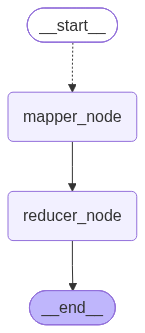

In [4]:
from operator import add
from typing import TypedDict, Annotated, Sequence

from IPython.display import display
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send
from loguru import logger


# 1、定义状态
# 1.1 声明全局状态
class OverAllState(TypedDict):
    input_values: list[str]
    entries: Annotated[list[tuple[str, int]], add]
    word_counts: dict[str, int]


# 中间节点
class MaperInputState(TypedDict):
    input_value: str


# 2、声明节点
# 2.1 分发节点
def router_node(state: OverAllState) -> Sequence[Send]:
    input_values = state["input_values"]
    task = []
    for input_value in input_values:
        task.append(
            Send("mapper_node", {"input_value": input_value})
        )
    return task


# 2.2 接受单独的一句话，切分为单词 族中为元组放到全局状态中
def mapper_node(state: MaperInputState) -> OverAllState:
    input_value = state["input_value"]
    # 将句子按空格拆分为单词（输入的句子分割只有空格）
    words = input_value.split(" ")
    # 数组，但里面存放的组()
    entries = []
    for word in words:
        entries.append((word, 1))
    return {
        "entries": entries
    }


# 2.3 聚合所有mapper_node拆分的元组进行合并
def reducer_node(state: OverAllState) -> OverAllState:
    entries = state["entries"]
    # 字典 key: 单词 value：单词在没给句子中出现次数
    shuffle_dict = {}
    for k, v in entries:
        if k not in shuffle_dict:
            shuffle_dict[k] = [v];
        else:
            shuffle_dict[k].append(v)

    logger.info("reducer shuffle entries:{}", shuffle_dict)
    reducer_dict = {}
    for k, v in shuffle_dict.items():
        # 累计每个单词出现的次数
        reducer_dict[k] = sum(v)
    logger.info("reducer {}", reducer_dict)
    return {
        "word_counts": reducer_dict
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("mapper_node", mapper_node)
builder.add_node("reducer_node", reducer_node)

builder.add_conditional_edges(START, router_node, path_map=["mapper_node"])
builder.add_edge("mapper_node", "reducer_node")
builder.add_edge("reducer_node", END)
graph = builder.compile()

# 调用图
res = graph.invoke({
    "input_values": ["hello world", "hello atguigu", "hello llm"]
})
print(res)

display(graph)